## Bước 1 – EDA (phân tích khám phá dữ liệu)

**[Bắt buộc]** Tối thiểu **5 hình vẽ**, mỗi hình phải có phần giải thích.

Mỗi hình viết ngắn theo 3 ý:

1. **Hình cho thấy gì?** (quan sát cụ thể, có con số)
2. **Ý nghĩa với bài toán?**
3. **Quyết định xử lý tiếp theo?** (nối sang bước 2, ví dụ "cột X lệch phải nên lấy log", "cột Y thiếu 30% nên điền median")

Gợi ý các hình (chọn ≥5, nên đa dạng loại biểu đồ):

| Hình | Trả lời câu hỏi |
|---|---|
| Phân bố biến mục tiêu (countplot/histogram) | Dữ liệu có mất cân bằng không? Loại bài toán là gì? |
| Phân bố biến số (histogram/boxplot) | Lệch không? Có ngoại lai không? |
| Bản đồ dữ liệu thiếu | Cột nào thiếu, thiếu bao nhiêu, có quy luật không? |
| Heatmap tương quan | Đặc trưng nào liên quan tới mục tiêu? Cặp nào trùng thông tin? |
| Đặc trưng vs mục tiêu (boxplot/violin/countplot) | Đặc trưng nào phân biệt được các lớp/giá trị? |
| Scatter/pairplot các đặc trưng chính | Quan hệ tuyến tính hay phi tuyến? Có cụm không? |

Lưu hình vào `docs/figures/` để dùng lại trong slide và báo cáo.

---



In [ ]:
from google.colab import files
from pathlib import Path
import shutil
import zipfile

ROOT = Path('/content/ckd_colab')
ROOT.mkdir(parents=True, exist_ok=True)
uploaded = files.upload()
zip_names = [name for name in uploaded if name.lower().endswith('.zip')]
if not zip_names:
    raise FileNotFoundError('Tệp dataset.zip không tồn tại trong ZIP.')
source = Path(zip_names[0])
shutil.copy2(source, ROOT / 'dataset.zip')
print('Đã lưu dataset:', ROOT / 'dataset.zip')
with zipfile.ZipFile(ROOT / 'dataset.zip') as archive:
    print('Nội dung ZIP:')
    for name in archive.namelist():
        print(' -', name)

Saving data.zip to data.zip
Đã lưu dataset: /content/ckd_colab/dataset.zip
Nội dung ZIP:
 - kidney_disease.csv


In [ ]:
from pathlib import Path
import io
import json
import zipfile
import numpy as np
import pandas as pd

ROOT = Path('/content/ckd_colab')
DATA_PATH = ROOT / 'dataset.zip'
MODEL_DIR = ROOT / 'models'
FIGURE_DIR = ROOT / 'docs' / 'figures'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

NUMERIC_FEATURES = ['age','bp','sg','al','su','bgr','bu','sc','sod','pot','hemo','pcv','wc','rc']
CATEGORICAL_FEATURES = ['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane']
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'classification'
POSITIVE_LABEL = 'ckd'
RANDOM_STATE = 42

def read_zip_dataset(path=DATA_PATH):
    if not Path(path).is_file():
        raise FileNotFoundError(f'Missing dataset file: {path}. Run notebook 01 first.')
    with zipfile.ZipFile(path) as archive:
        names = [name for name in archive.namelist() if name.lower().endswith('.csv')]
        if not names:
            raise FileNotFoundError('dataset.zip does not contain a CSV file.')
        print('Reading CSV from ZIP:', names[0])
        return pd.read_csv(io.BytesIO(archive.read(names[0])))

def clean_dataframe(dataframe):
    dataframe = dataframe.copy()
    dataframe.columns = dataframe.columns.astype(str).str.replace('\t','',regex=False).str.strip()
    for column in dataframe.select_dtypes(include=['object','string']).columns:
        dataframe[column] = dataframe[column].astype('string').str.replace('\t','',regex=False).str.strip().str.lower()
    for column in NUMERIC_FEATURES:
        dataframe[column] = pd.to_numeric(dataframe[column], errors='coerce').astype('float64')
    for column in CATEGORICAL_FEATURES:
        dataframe[column] = dataframe[column].astype('object').where(dataframe[column].notna(), np.nan)
    dataframe[TARGET] = dataframe[TARGET].astype('string').str.strip().str.lower().astype('object')
    if set(dataframe[TARGET].dropna().unique()) - {'ckd','notckd'}:
        raise ValueError('Target must contain only ckd and notckd.')
    if dataframe[TARGET].isna().any():
        raise ValueError('Target contains missing values.')
    return dataframe.drop_duplicates().reset_index(drop=True)
import matplotlib.pyplot as plt
import seaborn as sns

df = clean_dataframe(read_zip_dataset())
print('Cleaned shape:', df.shape)
print('Columns:', df.columns.tolist())
display(df.head())

Reading CSV from ZIP: kidney_disease.csv
Cleaned shape: (400, 26)
Columns: ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


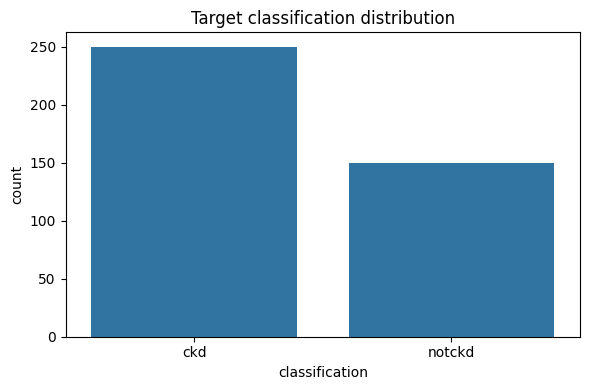

classification
ckd       250
notckd    150
Name: count, dtype: int64
Class counts and percentages:
  ckd: 250 samples (62.50%)
  notckd: 150 samples (37.50%)


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=TARGET)
plt.title('Target classification distribution')
plt.tight_layout(); plt.savefig(FIGURE_DIR/'01_target_distribution.png', dpi=160); plt.show()
print(df[TARGET].value_counts())

counts = df[TARGET].value_counts()
print('Class counts and percentages:')
for label, count in counts.items(): print(f'  {label}: {count} samples ({count/len(df)*100:.2f}%)')

### Giải thích Hình 1

1. Hình cho thấy số mẫu và tỷ lệ cụ thể của hai nhãn.
2. Đây là phân loại nhị phân lệch lớp vừa phải nên Accuracy một mình chưa đủ.
3. Quyết định: chia stratify; dùng F1, Recall, Precision, ROC-AUC và thử class weight trong CV.

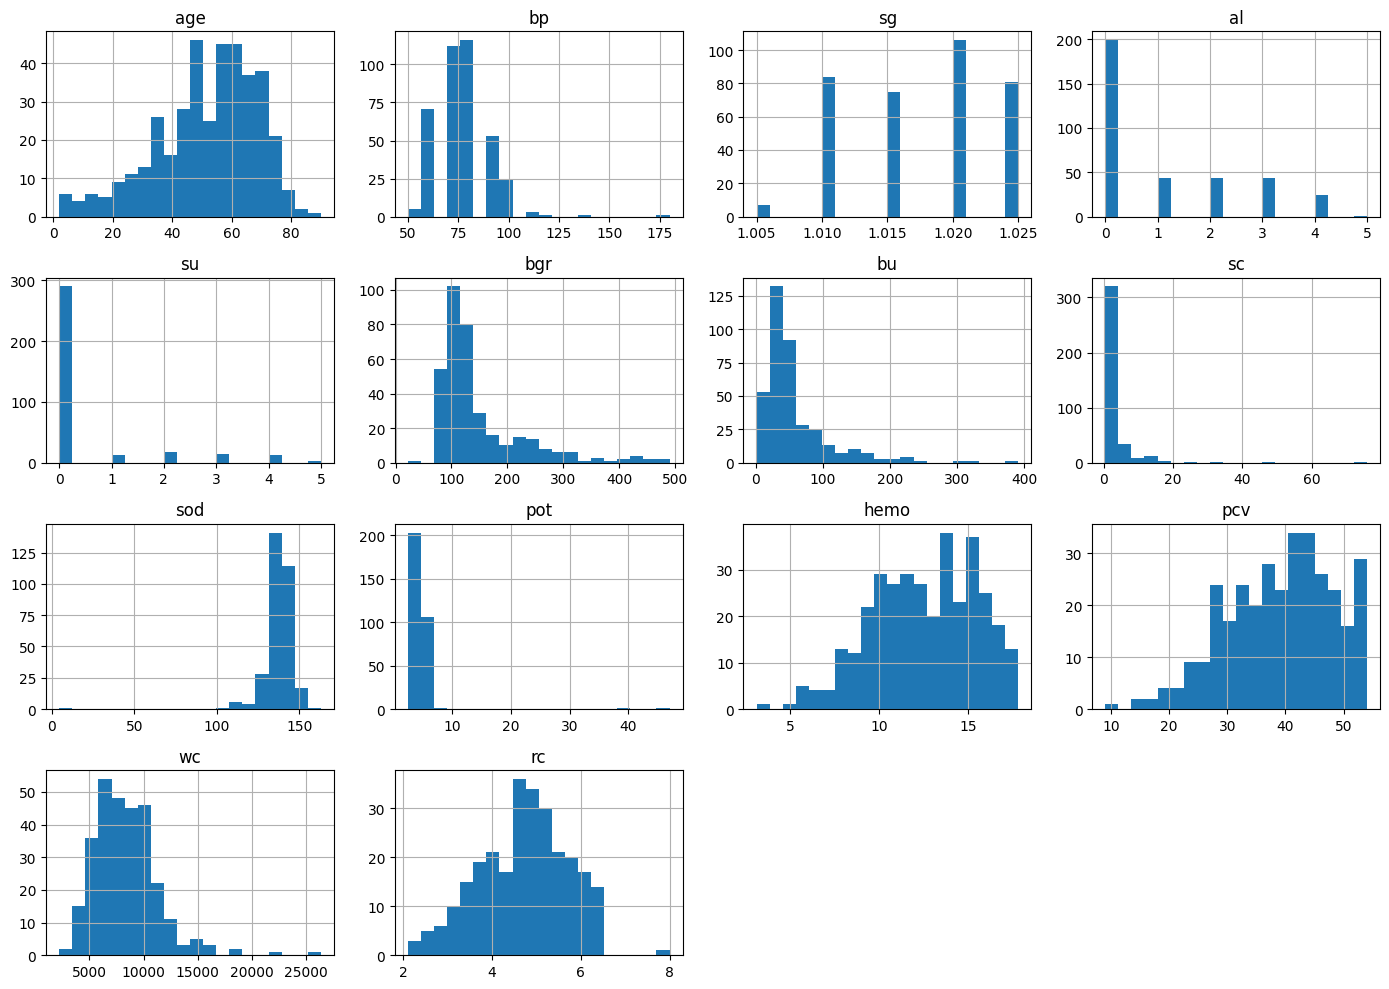

Numeric min/median/max:


,min,median,max
age,2.000,55.00,90.000
bp,50.000,80.00,180.000
sg,1.005,1.02,1.025
al,0.000,0.00,5.000
su,0.000,0.00,5.000
bgr,22.000,121.00,490.000
bu,1.500,42.00,391.000
sc,0.400,1.30,76.000
sod,4.500,138.00,163.000
pot,2.500,4.40,47.000


Giá trị nhỏ nhất / trung vị / lớn nhất:


,abs_skew
pot,11.582956
sc,7.509538
sod,6.996569
bu,2.634374
su,2.464262


In [ ]:
df[NUMERIC_FEATURES].hist(figsize=(14,10), bins=20)
plt.tight_layout(); plt.savefig(FIGURE_DIR/'02_numerical_distribution.png', dpi=160); plt.show()

print('Numeric min/median/max:')
display(df[NUMERIC_FEATURES].agg(['min','median','max']).T)
print('Giá trị nhỏ nhất / trung vị / lớn nhất:')
display(df[NUMERIC_FEATURES].skew().abs().sort_values(ascending=False).head(5).rename('abs_skew').to_frame())

### Giải thích Hình 2

1. Nhiều biến số lệch phải và có thang đo khác nhau.
2. KNN, SVM và Logistic Regression nhạy với thang đo; mean nhạy với cực trị.
3. Quyết định: median và StandardScaler trong pipeline chỉ fit trên train.

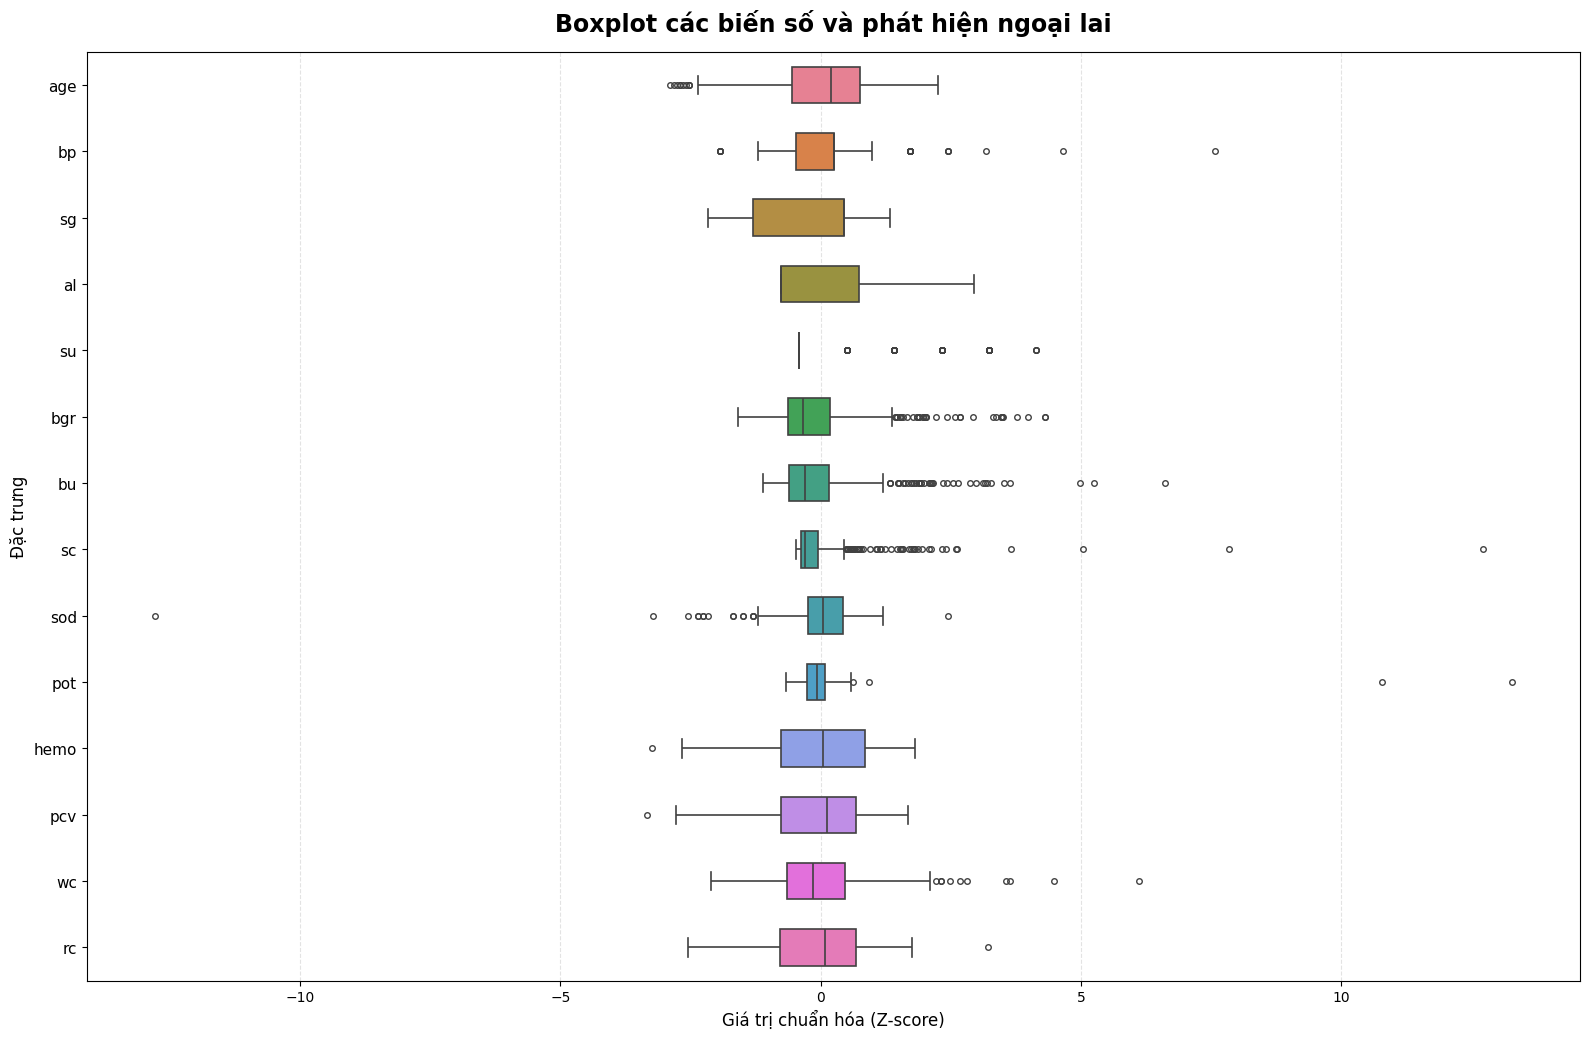

Số ngoại lai theo phương pháp IQR:


,outlier_count
su,61
sc,51
bu,38
bp,36
bgr,34
sod,16
age,10
wc,10
pot,4
hemo,1


Tổng số giá trị ngoại lai: 263


In [15]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ---------------------------------------------------------
# 1. Chuẩn hóa riêng cho mục đích trực quan hóa
# ---------------------------------------------------------
plot_df = pd.DataFrame(
    StandardScaler().fit_transform(
        df[NUMERIC_FEATURES]
    ),
    columns=NUMERIC_FEATURES
)


# ---------------------------------------------------------
# 2. Vẽ Boxplot
# ---------------------------------------------------------
plt.figure(
    figsize=(16, len(NUMERIC_FEATURES) * 0.75)
)

sns.boxplot(
    data=plot_df,
    orient="h",
    width=0.55,
    fliersize=4,
    linewidth=1.2
)

plt.title(
    "Boxplot các biến số và phát hiện ngoại lai",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Giá trị chuẩn hóa (Z-score)",
    fontsize=12
)

plt.ylabel(
    "Đặc trưng",
    fontsize=12
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=11)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "03_boxplot_outliers.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 3. Tính số lượng outlier theo IQR
#    Dùng dữ liệu GỐC, không dùng plot_df
# ---------------------------------------------------------
q1 = df[NUMERIC_FEATURES].quantile(0.25)
q3 = df[NUMERIC_FEATURES].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_counts = (
    (
        (df[NUMERIC_FEATURES] < lower_bound) |
        (df[NUMERIC_FEATURES] > upper_bound)
    )
    .sum()
    .sort_values(ascending=False)
)


# ---------------------------------------------------------
# 4. Hiển thị kết quả
# ---------------------------------------------------------
print("Số ngoại lai theo phương pháp IQR:")

display(
    outlier_counts[outlier_counts > 0]
    .to_frame("outlier_count")
)


# ---------------------------------------------------------
# 5. Tổng số outlier
# ---------------------------------------------------------
print(
    "Tổng số giá trị ngoại lai:",
    int(outlier_counts.sum())
)

### Giải thích Hình 3

1. Boxplot và bảng IQR cho biết ngoại lai của từng biến.
2. Cực trị y tế có thể là tín hiệu bệnh chứ không mặc nhiên là lỗi.
3. Quyết định: không xóa tự động; so sánh nhiều họ model.

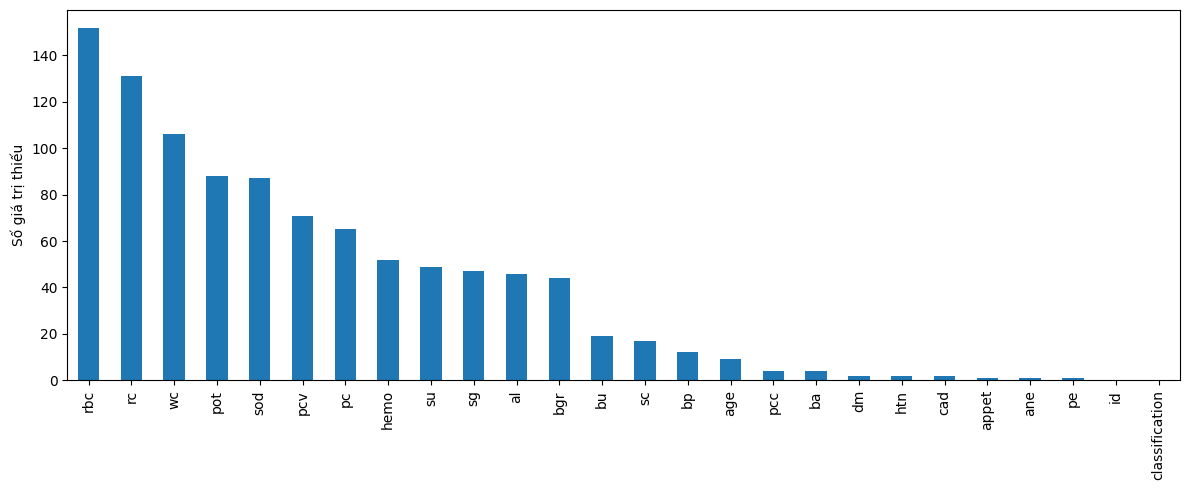

,missing_percent
rbc,38.00
rc,32.75
wc,26.50
pot,22.00
sod,21.75
pcv,17.75
pc,16.25
hemo,13.00
su,12.25
sg,11.75


Cột có nhiều giá trị thiếu nhất: rbc 152 (38.00%)


In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
plt.figure(figsize=(12,5)); missing.plot(kind='bar'); plt.ylabel('S\u1ed1 gi\u00e1 tr\u1ecb thi\u1ebfu')
plt.tight_layout(); plt.savefig(FIGURE_DIR/'04_missing_values.png', dpi=160); plt.show()
display((missing / len(df) * 100).round(2).rename('missing_percent').to_frame())

print('Cột có nhiều giá trị thiếu nhất:', missing.index[0], int(missing.iloc[0]), f'({missing.iloc[0]/len(df)*100:.2f}%)')

### Giải thích Hình 4

1. Cell trên cho biết số lượng và tỷ lệ thiếu cụ thể.
2. Bỏ dòng thiếu sẽ làm mất nhiều mẫu của bộ dữ liệu nhỏ.
3. Quyết định: numeric dùng median, categorical dùng mode trong pipeline.

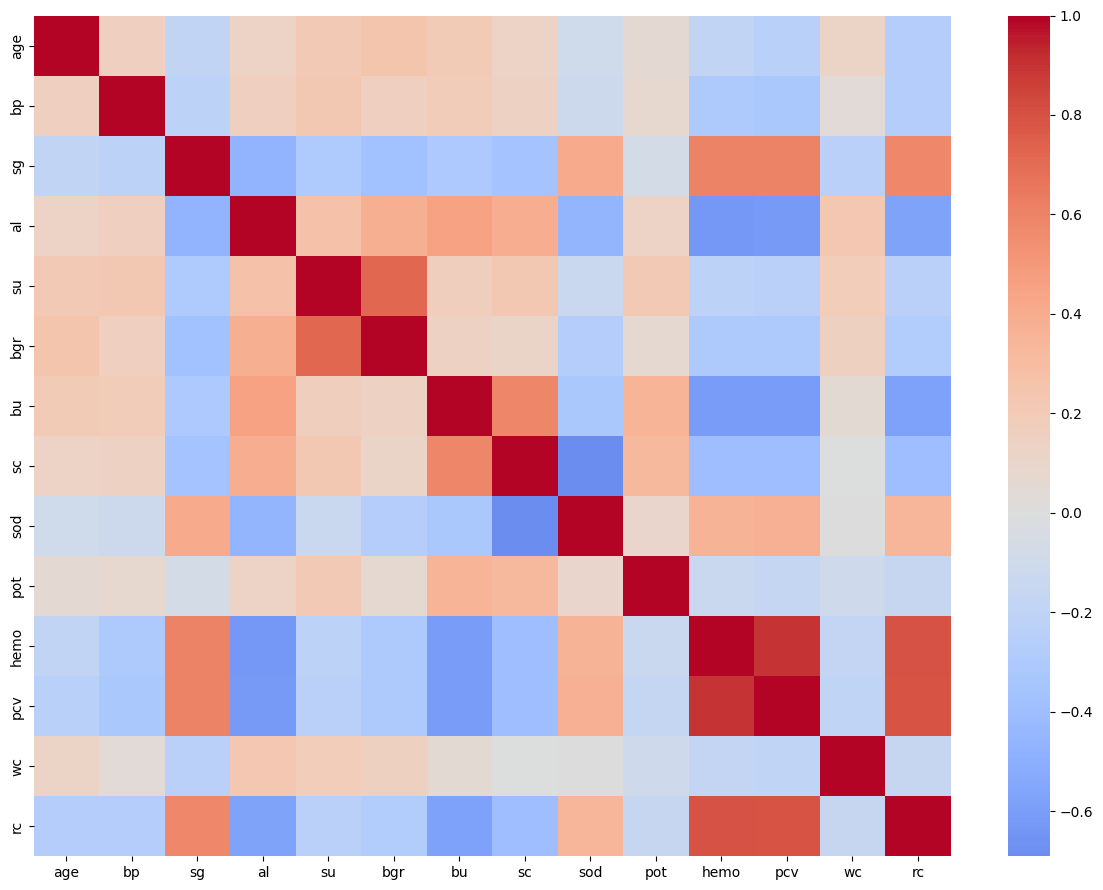

Strongest correlation pairs:


abs_correlation
hemo pcv         0.895382
     rc          0.798880
pcv  rc          0.791625
su   bgr         0.717827
sc   sod         0.690158

In [ ]:
plt.figure(figsize=(12,9))
sns.heatmap(df[NUMERIC_FEATURES].corr(), cmap='coolwarm', center=0)
plt.tight_layout(); plt.savefig(FIGURE_DIR/'05_correlation_heatmap.png', dpi=160); plt.show()

corr=df[NUMERIC_FEATURES].corr().abs(); pairs=corr.where(np.triu(np.ones(corr.shape),1).astype(bool)).stack().sort_values(ascending=False)
print('Strongest correlation pairs:'); display(pairs.head(5).rename('abs_correlation').to_frame())

### Giải thích Hình 5

1. Heatmap thể hiện tương quan giữa các biến số.
2. Tương quan cao gợi ý chồng lấp nhưng không chứng minh một biến vô ích.
3. Quyết định: giữ baseline; dùng regularization và CV thay vì xóa cảm tính.

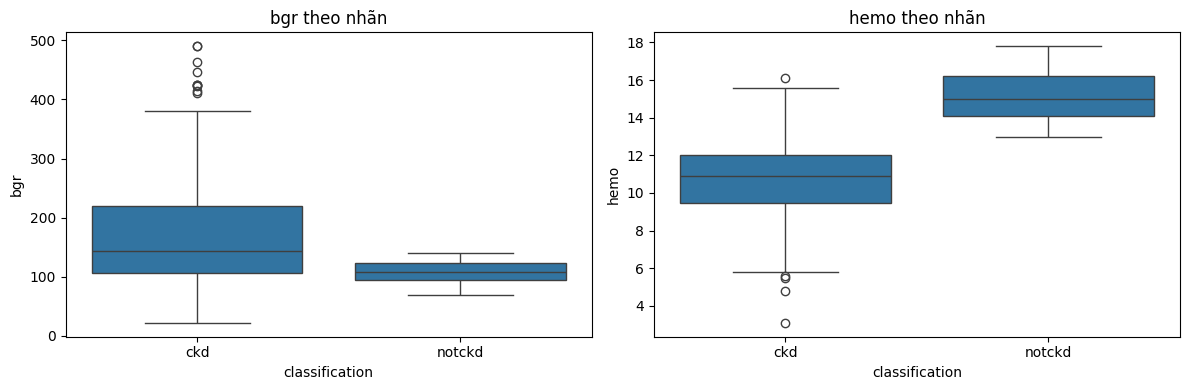

EDA hoàn tất. Hình đã lưu tại /content/ckd_colab/docs/figures
Trung vị đặc trưng theo nhãn:


,bgr,hemo
classification,,
ckd,143.5,10.9
notckd,107.5,15.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=df, x=TARGET, y='bgr', ax=axes[0]); axes[0].set_title('bgr theo nhãn')
sns.boxplot(data=df, x=TARGET, y='hemo', ax=axes[1]); axes[1].set_title('hemo theo nhãn')
plt.tight_layout(); plt.savefig(FIGURE_DIR/'06_feature_target.png', dpi=160); plt.show()
print('EDA hoàn tất. Hình đã lưu tại', FIGURE_DIR)

print('Trung vị đặc trưng theo nhãn:'); display(df.groupby(TARGET)[['bgr','hemo']].median())

### Giải thích Hình 6

1. Trung vị bgr và hemo khác nhau giữa hai nhãn.
2. Các biến có tín hiệu phân biệt và quan hệ có thể phi tuyến.
3. Quyết định: giữ cả hai và so sánh tuyến tính, khoảng cách, kernel và cây.

## Kết luận nối sang bước 2

Lệch lớp dẫn tới stratified split và nhiều metric. Thiếu dữ liệu dẫn tới median/mode. Khác thang đo dẫn tới StandardScaler. Ngoại lai y tế được giữ. Cột id bị loại vì chỉ là định danh.

In [ ]:
archive=shutil.make_archive(str(ROOT/'eda_figures'),'zip',FIGURE_DIR)
expected=['01_target_distribution.png','02_numerical_distribution.png','03_boxplot_outliers.png','04_missing_values.png','05_correlation_heatmap.png','06_feature_target.png']
assert all((FIGURE_DIR/name).is_file() for name in expected)
print('Created archive with all 6 figures:',archive)
files.download(archive)

Created archive with all 6 figures: /content/ckd_colab/eda_figures.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>